<div style="background-color:#1e1e1e; border: 3px solid #a855f7; border-radius: 10px; padding: 20px; text-align: center;">
    <h1 style="color:#c084fc;">Binary Classification RoBERTa Base Cosine Scheduler</h1>
    <h3 style="color:#e5e7eb;">Peningkatan Akurasi Menggunakan Advanced Text Cleansing dan Cosine Learning Rate Scheduler</h3>
</div>

Eksperimen ini difokuskan pada optimasi performa model RoBERTa dasar dengan menerapkan pembersihan teks tingkat lanjut (Advanced Cleansing) untuk menghilangkan noise seperti karakter khusus dan URL. Pelatihan didorong menggunakan Cosine Scheduler selama 20 Epoch penuh untuk mengatur dinamika proses belajar secara halus, memastikan model mencapai konvergensi optimal pada tahap akhir pelatihan.

### 1. Setup Lingkungan & Import Library

In [ ]:
!pip install transformers datasets evaluate accelerate -q

import pandas as pd
import numpy as np
import torch
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, TrainerCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


### 2. Pemrosesan Data Lanjutan

In [ ]:
path_dataset = '/COGNITIVE DISTORTION DATASET IN BAHASA INDONESIA COMPLETE.csv'
dataframe = pd.read_csv(path_dataset)

def bersihkan_teks(teks):
    teks = str(teks)
    teks = teks.replace('$', '')
    teks = re.sub(r'http\S+', '', teks)
    teks = re.sub(r'@\w+', '', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

dataframe['label'] = (dataframe['FIRST ANNOTATOR'] != 'No Distortion').astype(int)
dataframe['teks_bersih'] = dataframe['TEXT'].apply(bersihkan_teks)

df_asli = dataframe[dataframe['DATA STATUS'] == 'RAW-ORI'].copy()
df_augmentasi = dataframe[dataframe['DATA STATUS'] != 'RAW-ORI'].copy()

train_asli, test_df = train_test_split(df_asli, test_size=0.15, random_state=42, stratify=df_asli['label'])
train_df = pd.concat([train_asli, df_augmentasi], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = train_df[['teks_bersih', 'label']].rename(columns={'teks_bersih': 'text'})
test_df = test_df[['teks_bersih', 'label']].rename(columns={'teks_bersih': 'text'})

### 3. Inisialisasi Tokenizer & Model Dasar

In [ ]:
nama_model = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenizer = AutoTokenizer.from_pretrained(nama_model)

def fungsi_tokenisasi(contoh):
    return tokenizer(contoh['text'], padding="max_length", truncation=True, max_length=256)

train_dataset = Dataset.from_pandas(train_df).map(fungsi_tokenisasi, batched=True).remove_columns(['text'])
val_dataset = Dataset.from_pandas(test_df).map(fungsi_tokenisasi, batched=True).remove_columns(['text'])

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Map:   0%|          | 0/4292 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

### 4. Konfigurasi Pelatihan Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(nama_model, num_labels=2, ignore_mismatched_sizes=True)

def hitung_akurasi(prediksi):
    kategori_prediksi = prediksi.predictions.argmax(-1)
    return {'accuracy': accuracy_score(prediksi.label_ids, kategori_prediksi)}

riwayat_train = []

class PantauTrainCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, **kwargs):
        hasil = pelatih.predict(train_dataset)
        akurasi = accuracy_score(hasil.label_ids, hasil.predictions.argmax(-1))
        riwayat_train.append({'epoch': state.epoch, 'train_acc': akurasi, 'train_loss': hasil.metrics['test_loss']})

argumen_training = TrainingArguments(
    output_dir='./output_roberta_agrade',
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=30,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,
    report_to="none"
)

pelatih = Trainer(
    model=model,
    args=argumen_training,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=hitung_akurasi,
    callbacks=[PantauTrainCallback()]
)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprec

### 5. Eksekusi Pelatihan

In [ ]:
pelatih.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.633049,0.587593,0.690000
2,0.493290,0.497069,0.758571
3,0.383949,0.467769,0.771429
4,0.244262,0.619100,0.757143
5,0.145287,0.827149,0.767143
6,0.099061,1.194286,0.772857
7,0.074352,1.268332,0.801429
8,0.041956,1.533781,0.770000
9,0.027916,1.544086,0.781429
10,0.025172,1.678138,0.788571


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=8070, training_loss=0.07730164983144776, metrics={'train_runtime': 2738.3504, 'train_samples_per_second': 47.021, 'train_steps_per_second': 2.947, 'total_flos': 1.69390897440768e+16, 'train_loss': 0.07730164983144776, 'epoch': 30.0})

### 6. Visualisasi Riwayat Pelatihan (Loss & Accuracy)

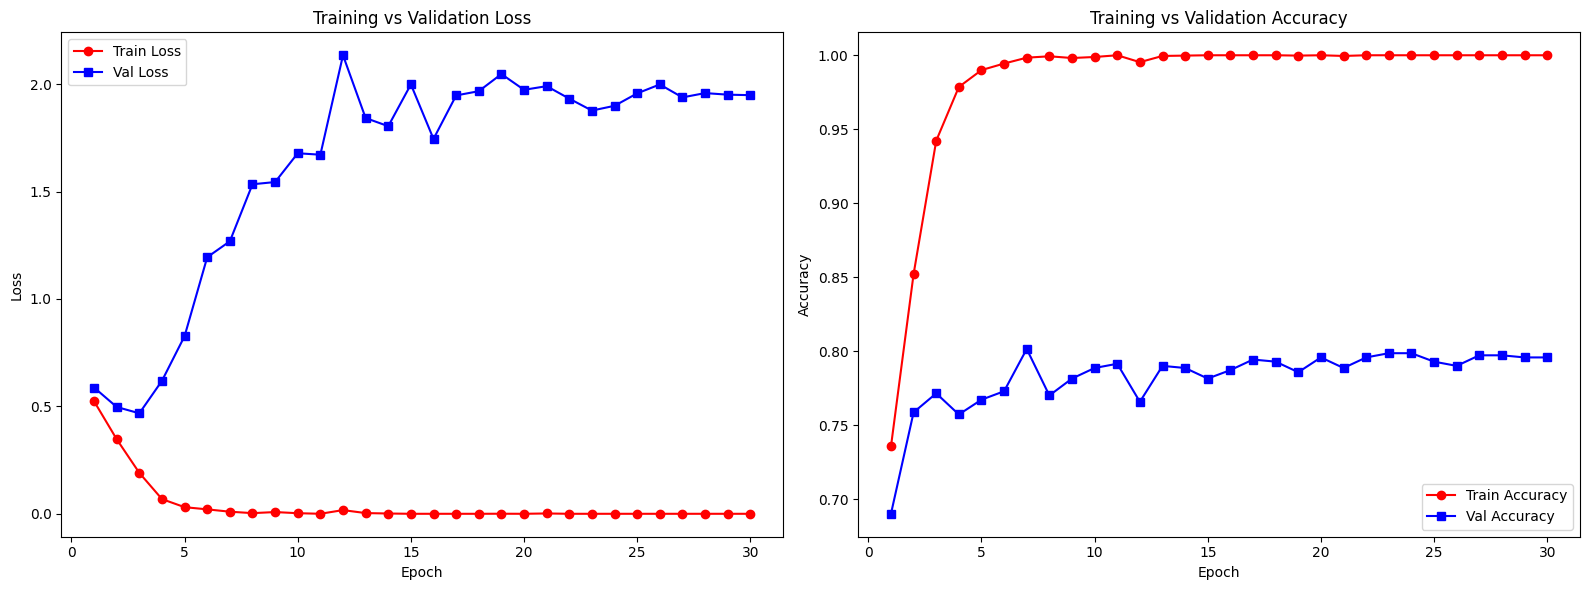

In [ ]:
riwayat_log = pelatih.state.log_history

val_epochs = []
val_loss_list = []
val_acc_list = []

for entry in riwayat_log:
    if 'eval_loss' in entry and 'eval_accuracy' in entry:
        val_epochs.append(entry['epoch'])
        val_loss_list.append(entry['eval_loss'])
        val_acc_list.append(entry['eval_accuracy'])

train_epochs = [r['epoch'] for r in riwayat_train]
train_loss_list = [r['train_loss'] for r in riwayat_train]
train_acc_list = [r['train_acc'] for r in riwayat_train]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(train_epochs, train_loss_list, 'r-o', label='Train Loss')
ax1.plot(val_epochs, val_loss_list, 'b-s', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()

ax2.plot(train_epochs, train_acc_list, 'r-o', label='Train Accuracy')
ax2.plot(val_epochs, val_acc_list, 'b-s', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()

fig.tight_layout()
plt.show()

### 7. Evaluasi Model Final (Threshold Optimization)

In [ ]:
prediksi_val = pelatih.predict(val_dataset)
label_val = prediksi_val.label_ids
probabilitas_val = torch.nn.functional.softmax(torch.tensor(prediksi_val.predictions), dim=-1)[:, 1].numpy()

akurasi_terbaik = 0
threshold_terbaik = 0.5
prediksi_terbaik = None

for batas in np.arange(0.4, 0.8, 0.01):
    prediksi_sementara = (probabilitas_val > batas).astype(int)
    akurasi = accuracy_score(label_val, prediksi_sementara)
    if akurasi > akurasi_terbaik:
        akurasi_terbaik = akurasi
        threshold_terbaik = batas
        prediksi_terbaik = prediksi_sementara

print(f"Akurasi Validasi Final: {akurasi_terbaik:.4f}")
print(f"Threshold Optimal: {threshold_terbaik:.2f}\n")
print(classification_report(label_val, prediksi_terbaik, target_names=['Normal (0)', 'Distorsi (1)']))

Akurasi Validasi Final: 0.8071
Threshold Optimal: 0.56

              precision    recall  f1-score   support

  Normal (0)       0.83      0.75      0.79       337
Distorsi (1)       0.79      0.86      0.82       363

    accuracy                           0.81       700
   macro avg       0.81      0.81      0.81       700
weighted avg       0.81      0.81      0.81       700



### 8. Confusion Matrix (Train vs Validation)

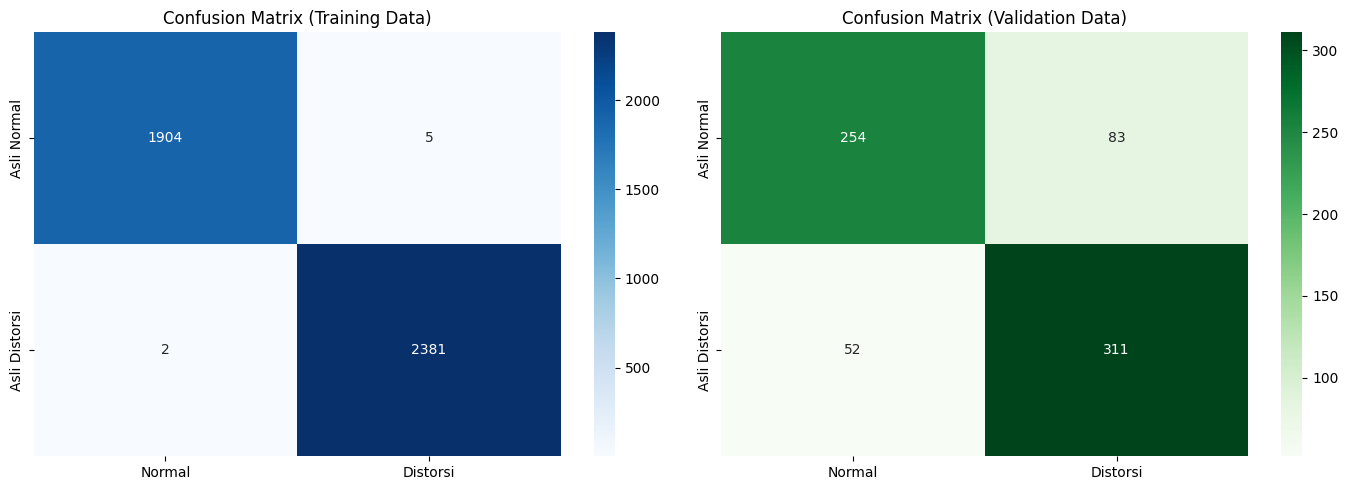

In [ ]:
prediksi_train = pelatih.predict(train_dataset)
label_train = prediksi_train.label_ids
probabilitas_train = torch.nn.functional.softmax(torch.tensor(prediksi_train.predictions), dim=-1)[:, 1].numpy()
prediksi_train_final = (probabilitas_train > threshold_terbaik).astype(int)

matriks_train = confusion_matrix(label_train, prediksi_train_final)
matriks_val = confusion_matrix(label_val, prediksi_terbaik)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(matriks_train, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=['Normal', 'Distorsi'], yticklabels=['Asli Normal', 'Asli Distorsi'])
ax1.set_title('Confusion Matrix (Training Data)')

sns.heatmap(matriks_val, annot=True, fmt='d', cmap='Greens', ax=ax2, xticklabels=['Normal', 'Distorsi'], yticklabels=['Asli Normal', 'Asli Distorsi'])
ax2.set_title('Confusion Matrix (Validation Data)')

plt.tight_layout()
plt.show()

In [ ]:
!zip -r /content/model_roberta_80_persen.zip /content/output_roberta_agrade

  adding: content/output_roberta_agrade/ (stored 0%)
  adding: content/output_roberta_agrade/checkpoint-1883/ (stored 0%)
  adding: content/output_roberta_agrade/checkpoint-1883/rng_state.pth (deflated 26%)
  adding: content/output_roberta_agrade/checkpoint-1883/config.json (deflated 52%)
  adding: content/output_roberta_agrade/checkpoint-1883/trainer_state.json (deflated 72%)
  adding: content/output_roberta_agrade/checkpoint-1883/scaler.pt (deflated 64%)
  adding: content/output_roberta_agrade/checkpoint-1883/optimizer.pt (deflated 32%)
  adding: content/output_roberta_agrade/checkpoint-1883/model.safetensors (deflated 7%)
  adding: content/output_roberta_agrade/checkpoint-1883/training_args.bin (deflated 53%)
  adding: content/output_roberta_agrade/checkpoint-1883/scheduler.pt (deflated 61%)


In [ ]:
from google.colab import files
files.download('/content/model_roberta_80_persen.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>